# Paper 1 - HRRP Penalty Reallocation under Social-Risk Adjustment

Single self-contained, reproducible notebook. **Policy simulation, not causal inference.**
Reporting: RECORD + PROGRESS-Plus. No fabricated numbers - every value is computed below.

**Research question.** Does re-stratifying HRRP peer groups by community Social Vulnerability
Index (SVI) instead of dual-eligible proportion shift penalty burden off hospitals serving the
most vulnerable communities? Run top-to-bottom. **Data is loaded from the bundled `data/` folder**
(read directly from disk; the notebook stops with a clear error if any file is missing).

## 0. Setup, configuration, and helpers

In [ ]:
import os, re, zipfile, math
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

PROJECT_ROOT = Path.cwd()
RAW = PROJECT_ROOT/'data'/'raw'; EXTERNAL = PROJECT_ROOT/'data'/'external'
PROCESSED = PROJECT_ROOT/'data'/'processed'
TABLES = PROJECT_ROOT/'outputs'/'tables'; FIGURES = PROJECT_ROOT/'outputs'/'figures'
for _p in (RAW, EXTERNAL, PROCESSED, TABLES, FIGURES):
    _p.mkdir(parents=True, exist_ok=True)

PENALTY_CAP = 0.03; N_SOCIAL_QUINTILES = 5
RANDOM_SEED = 42; N_BOOTSTRAP = 2000; CI_LEVEL = 0.95
PRIMARY_SVI_COL = 'RPL_THEMES'
CONDITIONS = ['AMI', 'COPD', 'HF', 'pneumonia', 'CABG', 'THA/TKA']
TAGS = [c.replace('/', '').lower() for c in CONDITIONS]

_CNTY = re.compile(r'\s+(COUNTY|PARISH|BOROUGH|CENSUS AREA|MUNICIPALITY|CITY AND BOROUGH|CITY)$')
def norm_county(name):
    if pd.isna(name): return None
    return re.sub(r'\s+', ' ', _CNTY.sub('', str(name).upper().strip())).strip()

def ownership_category(x):
    x = str(x)
    if 'Proprietary' in x or 'Physician' in x: return 'For-profit'
    if 'Voluntary non-profit' in x or 'Church' in x: return 'Nonprofit'
    if 'Government' in x or 'Tribal' in x or 'Federal' in x: return 'Government'
    return 'Other/Unknown'

REGION = {}
for _r, _s in {'Northeast':'CT ME MA NH RI VT NJ NY PA',
               'Midwest':'IL IN MI OH WI IA KS MN MO NE ND SD',
               'South':'DE FL GA MD NC SC VA DC WV AL KY MS TN AR LA OK TX',
               'West':'AZ CO ID MT NV NM UT WY AK CA HI OR WA'}.items():
    for _x in _s.split(): REGION[_x] = _r

def ci(a, level=CI_LEVEL):
    lo = (1-level)/2*100
    return float(np.nanpercentile(a, lo)), float(np.nanpercentile(a, 100-lo))

def _ncdf(z): return 0.5*(1+math.erf(z/math.sqrt(2)))

def ols_cluster(y, X, clusters):
    XtXi = np.linalg.pinv(X.T@X); beta = XtXi@(X.T@y)
    resid = y - X@beta; n, k = X.shape
    meat = np.zeros((k, k))
    for g in np.unique(clusters):
        idx = clusters == g; Xg = X[idx]; ug = resid[idx]; s = Xg.T@ug
        meat += np.outer(s, s)
    G = len(np.unique(clusters)); cor = (G/(G-1))*((n-1)/(n-k))
    V = cor * XtXi @ meat @ XtXi; se = np.sqrt(np.diag(V))
    pv = np.array([2*(1-_ncdf(abs(float(b/s)))) for b, s in zip(beta, se)])
    return beta, se, pv

def spearman(a, b):
    ra = pd.Series(np.asarray(a, float)).rank().to_numpy(); rb = pd.Series(np.asarray(b, float)).rank().to_numpy()
    rho = float(np.corrcoef(ra, rb)[0, 1]); nn = len(ra); z = rho*math.sqrt(max(nn-1, 1))
    return rho, 2*(1-_ncdf(abs(z)))

print('project root:', PROJECT_ROOT)

## 1. Data - loaded from the bundled `data/` directory

The five public datasets ship with this submission: CMS files in `data/raw/`, external SVI / Medicare
payments / ADI in `data/external/`. The notebook **loads them directly from disk** via the manifest
below - no downloads. (Original public sources are documented in the README and CODE_SUMMARY.)

In [2]:
# --- Data manifest: every file is loaded from the bundled data/ directory ----
DATA_FILES = {
    'hospital_readmissions': RAW / 'hospital_readmissions.csv',                # CMS HRRP Excess Readmission Ratios (FY2026)
    'hospital_general_info': RAW / 'hospital_general_info.csv',                # CMS Hospital General Information
    'hrrp_impact_file':      RAW / 'hrrp_impact_file.xlsx',                    # CMS FY2026 HRRP Supplemental (PAF, peer group, dual)
    'svi_county':            EXTERNAL / 'SVI_2022_US_county.csv',              # CDC/ATSDR SVI 2022 (county)
    'medicare_payments':     EXTERNAL / 'medicare_inpatient_by_provider.csv',  # Medicare inpatient payments (dollar base)
}
ADI_DIR = EXTERNAL / 'adi'   # optional ADI sensitivity (Neighborhood Atlas)

# Unzip the optional ADI download if only the zip is present (local, no network)
if not list(ADI_DIR.glob('*Block_Group*.csv')) and (EXTERNAL/'adi-download.zip').exists():
    zipfile.ZipFile(EXTERNAL/'adi-download.zip').extractall(ADI_DIR)

# All data ships with this submission under data/; verify it is present and load from disk
missing = [str(p.relative_to(PROJECT_ROOT)) for p in DATA_FILES.values() if not p.exists()]
assert not missing, 'Missing data file(s) - include the data/ folder: ' + ', '.join(missing)

print('Data loaded from directory (data/):')
for k, p in DATA_FILES.items():
    print('  [OK] %-22s -> %s' % (k, p.relative_to(PROJECT_ROOT)))
print('  [%s] %-22s -> %s' % ('OK' if list(ADI_DIR.glob('*Block_Group*.csv')) else '--', 'adi (optional)', 'data/external/adi/'))

Data loaded from directory (data/):
  [OK] hospital_readmissions  -> data\raw\hospital_readmissions.csv
  [OK] hospital_general_info  -> data\raw\hospital_general_info.csv
  [OK] hrrp_impact_file       -> data\raw\hrrp_impact_file.xlsx
  [OK] svi_county             -> data\external\SVI_2022_US_county.csv
  [OK] medicare_payments      -> data\external\medicare_inpatient_by_provider.csv
  [OK] adi (optional)         -> data/external/adi/


## 2. Build the facility-level dataset (FY2026 ERR + Hospital info + SVI)

In [3]:
def weighted_mean(err, w):
    err = pd.to_numeric(err, errors='coerce'); w = pd.to_numeric(w, errors='coerce')
    m = err.notna() & w.notna() & (w > 0)
    if m.sum() > 0 and w[m].sum() > 0:
        return float((err[m]*w[m]).sum()/w[m].sum())
    e = err.dropna(); return float(e.mean()) if len(e) else np.nan

def build_readmissions():
    df = pd.read_csv(RAW/'hospital_readmissions.csv', dtype=str, low_memory=False)
    df['ERR'] = pd.to_numeric(df['Excess Readmission Ratio'], errors='coerce')
    df['discharges'] = pd.to_numeric(df['Number of Discharges'], errors='coerce')
    rows = []
    for fid, sub in df.groupby('Facility ID'):
        rows.append({'facility_id': fid, 'state': sub['State'].iloc[0],
                     'n_measures_reported': int(sub['ERR'].notna().sum()),
                     'mean_err_wt': weighted_mean(sub['ERR'], sub['discharges']),
                     'total_discharges': float(pd.to_numeric(sub['discharges'], errors='coerce').dropna().sum())})
    out = pd.DataFrame(rows)
    return out[out['n_measures_reported'] > 0].reset_index(drop=True)

def load_general_info():
    g = pd.read_csv(RAW/'hospital_general_info.csv', dtype=str, low_memory=False)
    g = g.rename(columns={'Facility ID':'facility_id','State':'state_gi','ZIP Code':'zip',
                          'County/Parish':'county_name','Hospital Type':'hospital_type',
                          'Hospital Ownership':'ownership_raw'})
    g['ownership_cat'] = g['ownership_raw'].map(ownership_category)
    g['is_acute'] = g['hospital_type'].eq('Acute Care Hospitals')
    g['county_norm'] = g['county_name'].map(norm_county)
    return g[['facility_id','state_gi','zip','county_norm','hospital_type','ownership_cat','is_acute']]

def load_svi():
    svi = pd.read_csv(EXTERNAL/'SVI_2022_US_county.csv', low_memory=False)
    svi = svi[['ST_ABBR','COUNTY','FIPS',PRIMARY_SVI_COL,'RPL_THEME1','RPL_THEME2','RPL_THEME3','RPL_THEME4']].rename(
        columns={'ST_ABBR':'state', PRIMARY_SVI_COL:'svi_overall',
                 'RPL_THEME1':'svi_t1','RPL_THEME2':'svi_t2','RPL_THEME3':'svi_t3','RPL_THEME4':'svi_t4'})
    for _c in ['svi_overall','svi_t1','svi_t2','svi_t3','svi_t4']:
        svi[_c] = pd.to_numeric(svi[_c], errors='coerce').replace(-999.0, np.nan)
    svi['county_norm'] = svi['COUNTY'].map(norm_county)
    svi['county_fips'] = svi['FIPS'].astype(str).str.zfill(5)
    return svi[['state','county_norm','county_fips','svi_overall','svi_t1','svi_t2','svi_t3','svi_t4']].drop_duplicates(['state','county_norm'], keep='first')

rd = build_readmissions(); gi = load_general_info(); svi = load_svi()
df_fac = (rd.merge(gi, on='facility_id', how='inner').merge(svi, on=['state','county_norm'], how='left'))
df_fac['svi_quintile'] = pd.qcut(df_fac['svi_overall'], N_SOCIAL_QUINTILES, labels=list(range(1,6)))
df_fac.to_csv(PROCESSED/'analytic_facility.csv', index=False)
print('facilities:', len(df_fac), '| acute-care:', int(df_fac['is_acute'].sum()),
      '| SVI matched:', int(df_fac['svi_overall'].notna().sum()))

facilities: 2825 | acute-care: 2825 | SVI matched: 2743


## 3. Reproduce the official HRRP payment adjustment factor (validation gate)

`PAF = 1 - min(0.03, neutrality * sum_condition[ DRG_payment_ratio * max(0, ERR - peer_median) ])`.

In [4]:
def _find_col(cols, *toks):
    for c in cols:
        cl = str(c).lower()
        if all(t.lower() in cl for t in toks): return c
    return None

def load_impact(path):
    xl = pd.ExcelFile(path); sh = None
    for s in xl.sheet_names:
        probe = pd.read_excel(path, sheet_name=s, header=1, nrows=1)
        if _find_col(probe.columns, 'payment adjustment factor') and _find_col(probe.columns, 'ccn'): sh = s; break
    df = pd.read_excel(path, sheet_name=sh, header=1); df.columns = [str(c).strip() for c in df.columns]; cols = df.columns
    out = pd.DataFrame()
    out['ccn'] = df[_find_col(cols,'hospital ccn')].astype(str).str.replace(r'\.0$','',regex=True).str.zfill(6)
    out['paf'] = pd.to_numeric(df[_find_col(cols,'payment adjustment factor')], errors='coerce')
    out['dual_proportion'] = pd.to_numeric(df[_find_col(cols,'dual proportion')], errors='coerce')
    out['peer_group'] = pd.to_numeric(df[_find_col(cols,'peer group assignment')], errors='coerce')
    out['neutrality'] = pd.to_numeric(df[_find_col(cols,'neutrality modifier')], errors='coerce')
    for cond, tag in zip(CONDITIONS, TAGS):
        e=_find_col(cols,'ERR for '+cond); m=_find_col(cols,'median ERR for '+cond); d=_find_col(cols,'DRG payment ratio for '+cond)
        out['err_'+tag]=pd.to_numeric(df[e],errors='coerce') if e else np.nan
        out['med_'+tag]=pd.to_numeric(df[m],errors='coerce') if m else np.nan
        out['drg_'+tag]=pd.to_numeric(df[d],errors='coerce') if d else np.nan
    return out, sh

def total_excess(err_mat, drg_mat, med_mat):
    contrib = np.where(np.isfinite(err_mat) & np.isfinite(med_mat) & np.isfinite(drg_mat),
                       drg_mat*np.maximum(0.0, err_mat-med_mat), 0.0)
    return contrib.sum(axis=1)

df_off, sheet = load_impact(RAW/'hrrp_impact_file.xlsx')
EMo = df_off[['err_'+t for t in TAGS]].to_numpy(float); DMo = df_off[['drg_'+t for t in TAGS]].to_numpy(float)
MMo = df_off[['med_'+t for t in TAGS]].to_numpy(float)
paf_pred = 1.0 - np.minimum(PENALTY_CAP, df_off['neutrality'].to_numpy(float)*total_excess(EMo, DMo, MMo))
ok = df_off['paf'].notna() & np.isfinite(paf_pred)
mae = float(np.mean(np.abs(df_off['paf'][ok]-paf_pred[ok]))); corr = float(np.corrcoef(df_off['paf'][ok], paf_pred[ok])[0,1])
df_off.to_csv(PROCESSED/'official_supplemental.csv', index=False)
print('sheet:', sheet, '| hospitals:', len(df_off), '| penalized (PAF<1): %.1f%%' % (100*(df_off['paf']<1).mean()))
print('VALIDATION GATE -> MAE=%.5f  r=%.4f  within +/-0.0005: %.1f%%' % (mae, corr, 100*np.mean(np.abs(df_off['paf'][ok]-paf_pred[ok])<=0.0005)))

sheet: FR FY 2026 | hospitals: 2946 | penalized (PAF<1): 78.2%
VALIDATION GATE -> MAE=0.00016  r=0.9893  within +/-0.0005: 92.3%


## 4. PRIMARY - SVI peer grouping vs the actual dual-eligible grouping (dollar-neutral)

Peer groups are re-defined by SVI quintile and the payment reduction is recomputed. The neutrality
modifier is re-solved so that **total penalty dollars** (payment-weighted) are conserved, making the
per-hospital change a pure reallocation. Cohort restricted to hospitals with Medicare-payment data so
the percentage-point and dollar analyses share one cohort.

In [5]:
def row_medians(err, quint):
    med = np.full(len(err), np.nan)
    for q in range(1, N_SOCIAL_QUINTILES+1):
        sel = np.isfinite(err) & (quint == q)
        if sel.sum() > 0: med[quint == q] = np.median(err[sel])
    return med
def svi_median_matrix(err_mat, quint):
    out = np.full_like(err_mat, np.nan)
    for j in range(err_mat.shape[1]): out[:, j] = row_medians(err_mat[:, j], quint)
    return out
def solve_k_dollar(exc, nu, pay, target, cap=PENALTY_CAP):
    lo, hi = 0.0, 50.0
    for _ in range(45):
        mid = 0.5*(lo+hi)
        if float((pay*np.minimum(cap, mid*nu*exc)).sum()) < target: lo = mid
        else: hi = mid
    return 0.5*(lo+hi)

PAYDF = pd.read_csv(EXTERNAL/'medicare_inpatient_by_provider.csv', dtype=str, low_memory=False)
_ccnp = next(c for c in PAYDF.columns if 'CCN' in c.upper())
_payp = next((c for c in PAYDF.columns if c == 'Tot_Mdcr_Pymt_Amt'),
             next(c for c in PAYDF.columns if 'MDCR_PYMT' in c.upper() and 'TOT' in c.upper()))
PAYDF = PAYDF[[_ccnp, _payp]].rename(columns={_ccnp:'ccn', _payp:'pay'})
PAYDF['ccn'] = PAYDF['ccn'].astype(str).str.replace(r'\.0$','',regex=True).str.zfill(6)
PAYDF['pay'] = pd.to_numeric(PAYDF['pay'], errors='coerce')

gic = load_general_info().merge(load_svi(), on='county_norm', how='left', suffixes=('','_svi'))
gic = gic[gic['state_gi'] == gic['state']]
cf = df_off.merge(gic[['facility_id','ownership_cat','state_gi','county_norm','county_fips','svi_overall','svi_t1','svi_t2','svi_t3','svi_t4']].drop_duplicates('facility_id'),
                  left_on='ccn', right_on='facility_id', how='left')
cf = cf.merge(PAYDF, on='ccn', how='left')
cf = cf.merge(df_fac[['facility_id','total_discharges']].rename(columns={'facility_id':'ccn'}), on='ccn', how='left')
cf = cf[cf['svi_overall'].notna() & cf['neutrality'].notna() & cf['paf'].notna() & cf['pay'].notna()].copy()
cf['svi_quintile'] = pd.qcut(cf['svi_overall'], N_SOCIAL_QUINTILES, labels=list(range(1,6))).astype(int)
cf['region'] = cf['state_gi'].map(REGION).fillna('Other')
cf['cluster'] = cf['state_gi'].astype(str) + '_' + cf['county_norm'].astype(str)
_adi_files = list((EXTERNAL/'adi').glob('*Block_Group*.csv'))
if _adi_files:
    _adi = pd.read_csv(_adi_files[0], dtype=str)
    _adi['county_fips'] = _adi['FIPS'].astype(str).str.zfill(12).str[:5]
    _adi['adi'] = pd.to_numeric(_adi['ADI_NATRANK'], errors='coerce')
    _adic = _adi.dropna(subset=['adi']).groupby('county_fips')['adi'].median().rename('adi_county').reset_index()
    cf = cf.merge(_adic, on='county_fips', how='left')
    print('ADI county-matched:', int(cf['adi_county'].notna().sum()), 'of', len(cf))
else:
    cf['adi_county'] = np.nan
n = len(cf)
EM = cf[['err_'+t for t in TAGS]].to_numpy(float); DM = cf[['drg_'+t for t in TAGS]].to_numpy(float)
MO = cf[['med_'+t for t in TAGS]].to_numpy(float); NU = cf['neutrality'].to_numpy(float)
QU = cf['svi_quintile'].to_numpy(int); PAF = cf['paf'].to_numpy(); PAY = cf['pay'].to_numpy(float)
cf['mean_err'] = np.nanmean(EM, axis=1)

exc_obs = total_excess(EM, DM, MO); exc_svi = total_excess(EM, DM, svi_median_matrix(EM, QU))
red_obs = np.minimum(PENALTY_CAP, NU*exc_obs)
k_bn = solve_k_dollar(exc_svi, NU, PAY, float((PAY*red_obs).sum()))
red_svi = np.minimum(PENALTY_CAP, k_bn*NU*exc_svi)
cf['pen_obs'] = PAF < 1.0; cf['pen_svi'] = exc_svi > 0
cf['delta_pp'] = (red_svi - red_obs)*100
cf['delta_dollars'] = PAY*(red_svi - red_obs)
cf['changed'] = cf['pen_obs'] != cf['pen_svi']
print('cohort (SVI+official+payments):', n, '| dollar-neutral k=%.3f' % k_bn)
print('penalized: actual %.1f%% -> SVI grouping %.1f%%' % (100*cf['pen_obs'].mean(), 100*cf['pen_svi'].mean()))
print('total penalty $ conserved: obs=$%.1fM  svi=$%.1fM  (residual $%.3fM)'
      % ((PAY*red_obs).sum()/1e6, (PAY*red_svi).sum()/1e6, cf['delta_dollars'].sum()/1e6))
print('penalty status changed: %.2f%%' % (100*cf['changed'].mean()))

rng = np.random.default_rng(RANDOM_SEED); QS = list(range(1,6)); bdel = {q:[] for q in QS}
for _ in range(N_BOOTSTRAP):
    idx = rng.integers(0, n, n)
    em,dm,mo,nu,qz,py = EM[idx],DM[idx],MO[idx],NU[idx],QU[idx],PAY[idx]
    eo = total_excess(em,dm,mo); es = total_excess(em,dm,svi_median_matrix(em,qz))
    ro = np.minimum(PENALTY_CAP, nu*eo); kk = solve_k_dollar(es, nu, py, float((py*ro).sum()))
    dpp = (np.minimum(PENALTY_CAP, kk*nu*es) - ro)*100
    for q in QS:
        mq = qz == q
        if mq.sum() > 0: bdel[q].append(dpp[mq].mean())
rows = []
for q in QS:
    s = cf[cf['svi_quintile']==q]; dl,dh = ci(np.array(bdel[q]))
    rows.append({'svi_quintile':q,'n':len(s),'mean_delta_pp':round(s['delta_pp'].mean(),4),
                 'delta_ci_low':round(dl,4),'delta_ci_high':round(dh,4)})
by_q = pd.DataFrame(rows); by_q.to_csv(TABLES/'official_reallocation_by_svi.csv', index=False)
print('\nDollar-neutral reallocation by SVI quintile (pp):'); display(by_q)
print('By ownership (mean delta pp):', {k: round(v,4) for k,v in cf.groupby('ownership_cat')['delta_pp'].mean().items()})
print('By region (mean delta pp):', {k: round(v,4) for k,v in cf.groupby('region')['delta_pp'].mean().items()})
cf.to_csv(PROCESSED/'official_counterfactual.csv', index=False)

ADI county-matched: 2832 of 2832
cohort (SVI+official+payments): 2832 | dollar-neutral k=0.997
penalized: actual 78.6% -> SVI grouping 90.9%
total penalty $ conserved: obs=$368.4M  svi=$368.4M  (residual $0.000M)
penalty status changed: 12.71%



Dollar-neutral reallocation by SVI quintile (pp):


,svi_quintile,n,mean_delta_pp,delta_ci_low,delta_ci_high
0,1,569,0.0338,0.0132,0.0529
1,2,567,0.0195,0.0041,0.0360
2,3,563,0.0203,0.0008,0.0365
3,4,566,-0.0140,-0.0358,0.0035
4,5,567,-0.0410,-0.0599,-0.0233


By ownership (mean delta pp): {'For-profit': -0.0054, 'Government': -0.0005, 'Nonprofit': 0.0079}
By region (mean delta pp): {'Midwest': 0.021, 'Northeast': 0.0333, 'South': -0.0191, 'West': 0.0089}


## 4b. Dollar reallocation (same cohort; now conserves in dollars)

In [6]:
tot = float((cf['pay']*(1.0-cf['paf'])).sum())
realloc = float(np.abs(cf['delta_dollars']).sum()/2.0)
print('aggregate ACTUAL HRRP penalty (cohort): $%.1fM' % (tot/1e6))
print('dollars REALLOCATED (dollar-neutral SVI): $%.2fM (%.2f%% of penalties)' % (realloc/1e6, 100*realloc/tot))
dq = cf.groupby('svi_quintile')['delta_dollars'].agg(['size','sum','mean'])
dq['sum'] = (dq['sum']/1e6).round(3); dq['mean'] = dq['mean'].round(0); dq.columns = ['n','net_$M','mean_$_per_hosp']
dq.to_csv(TABLES/'official_reallocation_dollars_by_svi.csv'); display(dq)
cf.to_csv(PROCESSED/'official_counterfactual_dollars.csv', index=False)

aggregate ACTUAL HRRP penalty (cohort): $364.9M
dollars REALLOCATED (dollar-neutral SVI): $14.10M (3.86% of penalties)


,n,net_$M,mean_$_per_hosp
svi_quintile,,,
1,569,4.745,8340.0
2,567,3.070,5415.0
3,563,3.346,5942.0
4,566,-4.125,-7287.0
5,567,-7.037,-12410.0


## 4c. Statistical analysis (county-clustered inference)

(1) Is SVI distinct from the dual-eligible proportion? (2) Is the reallocation a monotonic function
of SVI? (3) Is SVI associated with readmissions **after adjusting for dual proportion**, ownership,
region, and size? Hospitals share county SVI, so all SVI inference uses **county-clustered** SEs.

In [7]:
sub = cf.dropna(subset=['svi_overall','dual_proportion'])
rho_sd, p_sd = spearman(sub['svi_overall'], sub['dual_proportion'])
print('(1) SVI vs dual proportion: Spearman rho=%.3f (p=%.2g), shared rank variance=%.1f%%' % (rho_sd, p_sd, 100*rho_sd**2))
if cf['adi_county'].notna().any():
    sa = cf.dropna(subset=['svi_overall', 'adi_county']); ra, pa = spearman(sa['svi_overall'], sa['adi_county'])
    print('(1b) SVI vs ADI (county): Spearman rho=%.3f (p=%.2g), shared rank variance=%.1f%%' % (ra, pa, 100*ra**2))

st = cf.dropna(subset=['svi_overall','delta_pp']).copy()
Xt = np.column_stack([np.ones(len(st)), st['svi_overall'].to_numpy(float)])
bt, set_, pt = ols_cluster(st['delta_pp'].to_numpy(float), Xt, st['cluster'].to_numpy())
print('(2) Trend delta_pp ~ SVI (county-clustered): slope=%.4f (95%% CI %.4f, %.4f), p=%.2g'
      % (bt[1], bt[1]-1.96*set_[1], bt[1]+1.96*set_[1], pt[1]))

reg = cf.dropna(subset=['mean_err','svi_overall','dual_proportion']).copy()
reg['logsize'] = np.log(pd.to_numeric(reg['total_discharges'], errors='coerce').fillna(
    pd.to_numeric(reg['total_discharges'], errors='coerce').median())+1)
Xd = pd.concat([pd.Series(1.0, index=reg.index, name='const'),
                reg['svi_overall'].rename('SVI').astype(float),
                reg['dual_proportion'].rename('DUAL').astype(float), reg['logsize'],
                pd.get_dummies(reg['ownership_cat'], prefix='own', drop_first=True).astype(float),
                pd.get_dummies(reg['region'], prefix='reg', drop_first=True).astype(float)], axis=1)
bb, sb, pb = ols_cluster(reg['mean_err'].to_numpy(float), Xd.to_numpy(float), reg['cluster'].to_numpy())
isvi = list(Xd.columns).index('SVI'); idu = list(Xd.columns).index('DUAL')
print('(3) Adjusted ERR ~ SVI + dual + ownership + region + size (county-clustered), n=%d:' % len(reg))
print('    SVI  coef=%.4f (95%% CI %.4f, %.4f), p=%.2g' % (bb[isvi], bb[isvi]-1.96*sb[isvi], bb[isvi]+1.96*sb[isvi], pb[isvi]))
print('    DUAL coef=%.4f (95%% CI %.4f, %.4f), p=%.2g' % (bb[idu], bb[idu]-1.96*sb[idu], bb[idu]+1.96*sb[idu], pb[idu]))

(1) SVI vs dual proportion: Spearman rho=0.305 (p=0), shared rank variance=9.3%
(1b) SVI vs ADI (county): Spearman rho=0.271 (p=0), shared rank variance=7.4%


(2) Trend delta_pp ~ SVI (county-clustered): slope=-0.0903 (95% CI -0.1025, -0.0782), p=0


(3) Adjusted ERR ~ SVI + dual + ownership + region + size (county-clustered), n=2832:
    SVI  coef=0.0067 (95% CI -0.0046, 0.0180), p=0.25
    DUAL coef=0.0712 (95% CI 0.0513, 0.0910), p=2.1e-12


## 4d. Sensitivity to the social-risk index and cut-points

Does the reallocation depend on using SVI-overall with quintiles? We re-run the dollar-neutral
counterfactual under alternative cut-points (tertiles, deciles) and alternative SVI sub-theme indices
(socioeconomic; household composition/disability; minority/language; housing/transport), reporting the
mean change in payment reduction for the most- vs least-vulnerable group.

In [8]:
def _med_mat(err_mat, q):
    out = np.full_like(err_mat, np.nan)
    for j in range(err_mat.shape[1]):
        col = err_mat[:, j]
        for gg in np.unique(q[q > 0]):
            sel = (q == gg) & np.isfinite(col)
            if sel.sum() > 0: out[(q == gg), j] = np.median(col[sel])
    return out

def run_cf(gv, ngroups):
    gv = np.asarray(gv, float); valid = np.isfinite(gv); g = np.full(len(gv), np.nan)
    g[valid] = pd.qcut(pd.Series(gv[valid]), ngroups, labels=list(range(1, ngroups+1)),
                       duplicates='drop').astype(float).to_numpy()
    qint = np.where(np.isfinite(g), g, -1).astype(int)
    es = total_excess(EM, DM, _med_mat(EM, qint))
    kk = solve_k_dollar(es, NU, PAY, float((PAY*red_obs).sum()))
    dpp = (np.minimum(PENALTY_CAP, kk*NU*es) - red_obs)*100
    return g, dpp

specs = [('SVI overall, quintiles', cf['svi_overall'].to_numpy(), 5),
         ('SVI overall, tertiles', cf['svi_overall'].to_numpy(), 3),
         ('SVI overall, deciles', cf['svi_overall'].to_numpy(), 10),
         ('Socioeconomic theme, quintiles', cf['svi_t1'].to_numpy(), 5),
         ('Household/disability theme, quintiles', cf['svi_t2'].to_numpy(), 5),
         ('Minority/language theme, quintiles', cf['svi_t3'].to_numpy(), 5),
         ('Housing/transport theme, quintiles', cf['svi_t4'].to_numpy(), 5)]
if cf['adi_county'].notna().sum() > 100:
    specs.append(('Area Deprivation Index (ADI 2023), quintiles', cf['adi_county'].to_numpy(), 5))
out = []
for name, gv, ng in specs:
    g, dpp = run_cf(gv, ng)
    top = np.nanmax(g); bot = np.nanmin(g)
    out.append({'specification': name,
                'most_vuln_delta_pp': round(float(np.nanmean(dpp[g == top])), 4),
                'least_vuln_delta_pp': round(float(np.nanmean(dpp[g == bot])), 4)})
sens = pd.DataFrame(out); sens.to_csv(TABLES/'sensitivity_index_cutpoints.csv', index=False)
print('Most- vs least-vulnerable mean change in payment reduction (pp), by specification:'); display(sens)

Most- vs least-vulnerable mean change in payment reduction (pp), by specification:


,specification,most_vuln_delta_pp,least_vuln_delta_pp
0,"SVI overall, quintiles",-0.0410,0.0338
1,"SVI overall, tertiles",-0.0375,0.0342
2,"SVI overall, deciles",-0.0255,0.0470
3,"Socioeconomic theme, quintiles",-0.0393,0.0383
4,"Household/disability theme, quintiles",-0.0157,0.0440
5,"Minority/language theme, quintiles",-0.0309,0.0489
6,"Housing/transport theme, quintiles",-0.0024,0.0119
7,"Area Deprivation Index (ADI 2023), quintiles",-0.0210,0.0083


## 5. Robustness - simplified operationalization (FY2026 non-stratified vs SVI-stratified median flag)

In [9]:
fac = df_fac[df_fac['is_acute'] & df_fac['mean_err_wt'].notna() & df_fac['svi_quintile'].notna()].copy()
fac['svi_quintile'] = fac['svi_quintile'].astype(int)
perf = fac['mean_err_wt'].to_numpy(); quint = fac['svi_quintile'].to_numpy()
def flags(perf, quint):
    f_ns = perf > np.median(perf); f_ss = np.zeros(len(perf), bool)
    for q in range(1,6):
        m = quint == q
        if m.sum() > 0: f_ss[m] = perf[m] > np.median(perf[m])
    return f_ns, f_ss
f_ns, f_ss = flags(perf, quint); fac['f_ns'], fac['f_ss'] = f_ns, f_ss
print('FY2026 robustness cohort:', len(fac), '| reclassified: %.2f%%' % (100*np.mean(f_ns != f_ss)))
di = (fac.groupby('svi_quintile')[['f_ns','f_ss']].mean()*100).round(1)
di.columns = ['flag_rate_nonstrat','flag_rate_svistrat']; di.to_csv(TABLES/'disparate_impact_flagrates.csv'); display(di)
print('Q5/Q1 flag-rate ratio  non-stratified %.3f  ->  SVI-stratified %.3f' % (
    di['flag_rate_nonstrat'].iloc[-1]/di['flag_rate_nonstrat'].iloc[0],
    di['flag_rate_svistrat'].iloc[-1]/di['flag_rate_svistrat'].iloc[0]))

FY2026 robustness cohort: 2743 | reclassified: 6.74%


,flag_rate_nonstrat,flag_rate_svistrat
svi_quintile,,
1,43.5,49.9
2,44.0,50.0
3,45.6,49.9
4,53.3,50.0
5,63.7,49.9


Q5/Q1 flag-rate ratio  non-stratified 1.464  ->  SVI-stratified 1.000


## 6. Figure 1 - reallocation (FY2026 official, dollar-neutral) and flag-rate parity (FY2026)

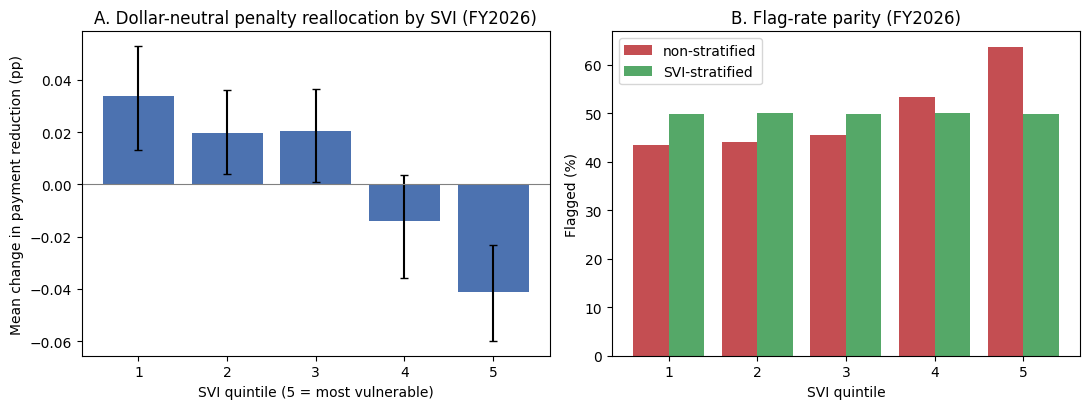

In [10]:
fig, ax = plt.subplots(1, 2, figsize=(11, 4.2))
ax[0].bar(by_q['svi_quintile'], by_q['mean_delta_pp'], color='#4C72B0')
ax[0].errorbar(by_q['svi_quintile'], by_q['mean_delta_pp'],
               yerr=[by_q['mean_delta_pp']-by_q['delta_ci_low'], by_q['delta_ci_high']-by_q['mean_delta_pp']],
               fmt='none', ecolor='black', capsize=3)
ax[0].axhline(0, color='grey', lw=0.8)
ax[0].set_xlabel('SVI quintile (5 = most vulnerable)'); ax[0].set_ylabel('Mean change in payment reduction (pp)')
ax[0].set_title('A. Dollar-neutral penalty reallocation by SVI (FY2026)')
ax[1].bar(np.array(di.index)-0.2, di['flag_rate_nonstrat'], width=0.4, label='non-stratified', color='#C44E52')
ax[1].bar(np.array(di.index)+0.2, di['flag_rate_svistrat'], width=0.4, label='SVI-stratified', color='#55A868')
ax[1].set_xlabel('SVI quintile'); ax[1].set_ylabel('Flagged (%)')
ax[1].set_title('B. Flag-rate parity (FY2026)'); ax[1].legend()
fig.tight_layout(); fig.savefig(FIGURES/'fig_equity_reallocation.png', dpi=150, bbox_inches='tight'); plt.show()

## 7. Summary

Validation gate passed (MAE ~0.0002). Holding total penalty **dollars** constant, re-grouping peers by
SVI shifts burden off the most vulnerable hospitals (county-clustered trend p<0.001). SVI is only
modestly correlated with dual proportion and, after adjusting for it, is **not** independently associated
with readmissions (p=0.25) - so SVI acts as a transparent redistribution lever, not a better predictor.
A simplified-operationalization check reproduces the direction.